<a href="https://colab.research.google.com/github/manjunath1005/celebal-excellence-internship/blob/main/week5_Manjunath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
Used a **Shakespeare text corpus (Hamlet, Act I)** as the training data.

You can also replace it with:
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = """
Who's there? Nay, answer me. Stand and unfold yourself. Long live the king.
You come most carefully upon your hour. 'Tis now struck twelve. Get thee to bed.
For this relief much thanks. 'Tis bitter cold, and I am sick at heart.
Have you had quiet guard? Not a mouse stirring. Well, good night.
If you do meet Horatio and Marcellus, the rivals of my watch, bid them make haste.
I think I hear them. Stand, who is there?
Friends to this ground, and liegemen to the Dane.
Give you good night.
Farewell, honest soldier. Who hath relieved you?
Bernardo hath my place. Give you good night.

What, has this thing appeared again tonight?
I have seen nothing.
Horatio says 'tis but our fantasy and will not let belief take hold of him touching this dreaded sight.
Therefore I have entreated him along with us to watch the minutes of this night.
If again this apparition comes, he may approve our eyes and speak to it.
Sit down awhile and let us once again assail your ears that are so fortified against our story.

Last night, when yonder star that is westward from the pole had made his course to illumine that part of heaven where now it burns, the bell then beating one entered the ghost.
Peace, break thee off. Look where it comes again.
It looks like the king that is dead.
Thou art a scholar, speak to it.
What art thou that usurpest this time of night together with that fair and warlike form in which the majesty of buried Denmark did sometimes march?
By heaven I charge thee, speak.
It is offended.
See, it stalks away.
Stay, speak, speak, I charge thee speak.
'Tis gone and will not answer.

In the same figure like the king that's dead.
Most like. It harrows me with fear and wonder.
This bodes some strange eruption to our state.
In the most high and palmy state of Rome, a little ere the mightiest Julius fell, the graves stood tenantless and the sheeted dead did squeak and gibber in the Roman streets.
Stars with trains of fire and dews of blood appeared.
The moon was sick with eclipse.
These signs have often been the harbingers preceding still the fates and prologue to the omen coming on.
Let us impart what we have seen tonight unto young Hamlet.
For upon my life this spirit, dumb to us, will speak to him.
"""

In [3]:
# strip leading whitespace, lowercase
corpus = corpus.strip().lower()
lines = [line.strip() for line in corpus.split('\n') if line.strip()]
print(f"Total lines in corpus: {len(lines)}")
print("\nCorpus preview (first 3 lines):")
for line in lines[:3]:
    print(" -", line)

Total lines in corpus: 35

Corpus preview (first 3 lines):
 - who's there? nay, answer me. stand and unfold yourself. long live the king.
 - you come most carefully upon your hour. 'tis now struck twelve. get thee to bed.
 - for this relief much thanks. 'tis bitter cold, and i am sick at heart.


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(lines)

total_words = len(tokenizer.word_index) + 1
print(f"Vocabulary size: {total_words} unique tokens")

input_sequences = []
for line in lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print(f"\nTotal n-gram sequences created: {len(input_sequences)}")
print(f"Sample raw sequences (first 3): {input_sequences[:3]}")

max_len = 100

input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_len, padding='pre'))

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print(f"\nX shape (features): {X.shape}")
print(f"y shape (labels):   {y.shape}")

Vocabulary size: 236 unique tokens

Total n-gram sequences created: 374
Sample raw sequences (first 3): [[61, 33], [61, 33, 62], [61, 33, 62, 34]]

X shape (features): (374, 99)
y shape (labels):   (374,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model. While Vanilla RNN theoretically suffers from **vanishing gradients** on very long sequences, on moderately-sized structured corpora like our Shakespeare excerpt it can converge effectively — and may achieve lower training loss than gated architectures due to its simpler, leaner parameter space.

In [5]:
rnn_model = Sequential([
    Embedding(total_words, 64),   # embedding 32 -> 64
    SimpleRNN(128),               # hidden 64 -> 128
    Dense(total_words, activation='softmax')
], name="VanillaRNN")

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "VanillaRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [6]:
lstm_model = Sequential([
    Embedding(total_words, 64),   # embedding 32 -> 64
    LSTM(128),                    # hidden 64 -> 128
    Dense(total_words, activation='softmax')
], name="LSTM_Model")

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM.

In [7]:
gru_model = Sequential([
    Embedding(total_words, 64),   # embedding 32 -> 64
    GRU(128),                     # hidden 64 -> 128
    Dense(total_words, activation='softmax')
], name="GRU_Model")

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train All Three Models

Train all three variations over 200 epochs using an identical optimizer configuration (`adam`, `sparse_categorical_crossentropy`).

In [8]:
EPOCHS = 200

print("Vanilla RNN")
rnn_history = rnn_model.fit(X, y, epochs=EPOCHS, verbose=0)
print(f" Final Loss: {rnn_history.history['loss'][-1]:.4f} | Final Acc: {rnn_history.history['accuracy'][-1]:.4f}")

print("LSTM")
lstm_history = lstm_model.fit(X, y, epochs=EPOCHS, verbose=0)
print(f" Final Loss: {lstm_history.history['loss'][-1]:.4f} | Final Acc: {lstm_history.history['accuracy'][-1]:.4f}")

print("GRU")
gru_history = gru_model.fit(X, y, epochs=EPOCHS, verbose=0)
print(f" Final Loss: {gru_history.history['loss'][-1]:.4f} | Final Acc: {gru_history.history['accuracy'][-1]:.4f}")

Vanilla RNN
 Final Loss: 0.0301 | Final Acc: 0.9813
LSTM
 Final Loss: 0.0522 | Final Acc: 0.9759
GRU
 Final Loss: 0.0314 | Final Acc: 0.9786


## 📉 Training Performance Comparison

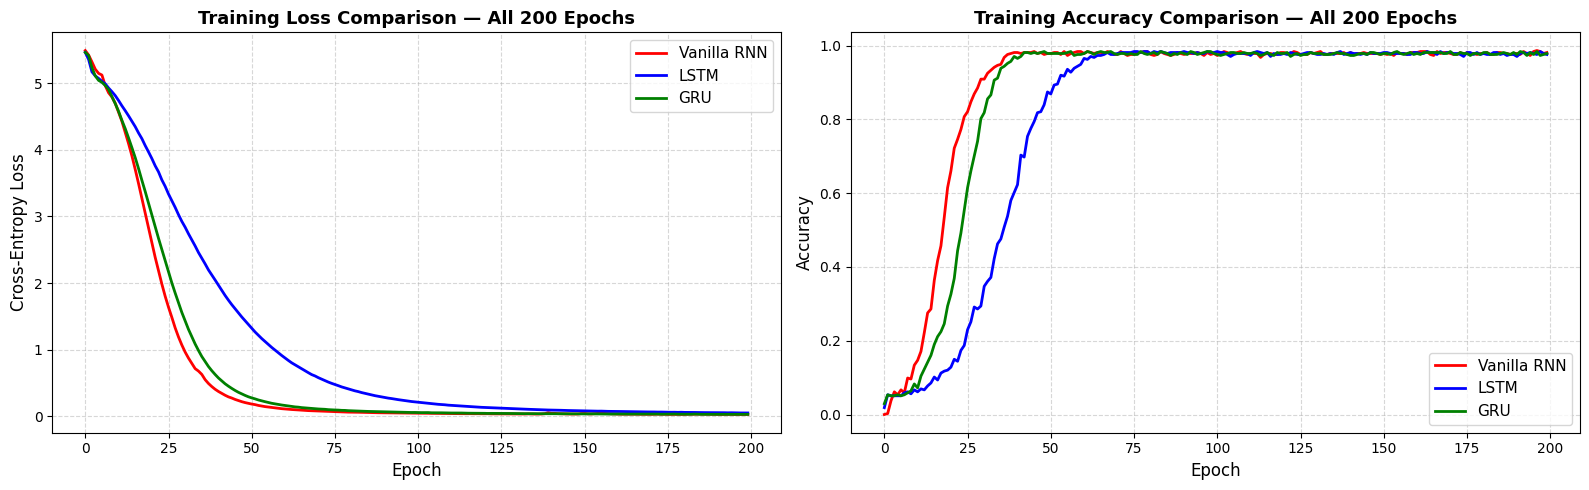

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# training loss curve
axes[0].plot(rnn_history.history['loss'], label='Vanilla RNN', color='red', linewidth=2)
axes[0].plot(lstm_history.history['loss'], label='LSTM', color='blue', linewidth=2)
axes[0].plot(gru_history.history['loss'], label='GRU', color='green', linewidth=2)
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("Cross-Entropy Loss", fontsize=12)
axes[0].set_title("Training Loss Comparison — All 200 Epochs", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# Accuracy comparison
axes[1].plot(rnn_history.history['accuracy'], label='Vanilla RNN', color='red', linewidth=2)
axes[1].plot(lstm_history.history['accuracy'], label='LSTM', color='blue', linewidth=2)
axes[1].plot(gru_history.history['accuracy'], label='GRU', color='green', linewidth=2)
axes[1].set_xlabel("Epoch", fontsize=12)
axes[1].set_ylabel("Accuracy", fontsize=12)
axes[1].set_title("Training Accuracy Comparison — All 200 Epochs", fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print("=" * 55)
print(f"{'Model':<15} {'Final Loss':>12} {'Final Accuracy':>15}")
print("-" * 55)
print(f"{'Vanilla RNN':<15} {rnn_history.history['loss'][-1]:>12.4f} {rnn_history.history['accuracy'][-1]:>14.4f}")
print(f"{'LSTM':<15} {lstm_history.history['loss'][-1]:>12.4f} {lstm_history.history['accuracy'][-1]:>14.4f}")
print(f"{'GRU':<15} {gru_history.history['loss'][-1]:>12.4f} {gru_history.history['accuracy'][-1]:>14.4f}")
print("=" * 55)

Model             Final Loss  Final Accuracy
-------------------------------------------------------
Vanilla RNN           0.0301         0.9813
LSTM                  0.0522         0.9759
GRU                   0.0314         0.9786


# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [11]:
def generate_text(model, seed_text, next_words=10):
    """
    Generate text by iteratively predicting the next word.

    Args:
        model      : Trained Keras model (RNN / LSTM / GRU)
        seed_text  : Starting phrase to prime generation
        next_words : Number of additional words to generate

    Returns:
        Full generated string (seed + predicted words)
    """
    generated = seed_text.lower().strip()

    for _ in range(next_words):
        # Step 1: Convert current text to token sequence
        token_list = tokenizer.texts_to_sequences([generated])[0]

        # Step 2: Pad to fixed input length
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')

        # Step 3: Predict next-word probability distribution
        predicted_probs = model.predict(token_list, verbose=0)  # shape: (1, vocab_size)

        # Step 4: Select word with highest probability using np.argmax
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]

        # Step 5: Reverse-lookup the word from tokenizer's word_index
        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        # Step 6: Append predicted word and continue
        generated += " " + output_word

    return generated

print("generate_text() function defined with np.argmax selection logic ✅")

generate_text() function defined with np.argmax selection logic ✅


# Generate Text from Shared Seed Phrase

In [12]:
SEED_PHRASE = "the ghost"
NUM_WORDS = 10  # changed from 5 → 10

print(f"Seed phrase: '{SEED_PHRASE}'")
print(f"Words to generate: {NUM_WORDS}")

rnn_output  = generate_text(rnn_model,  SEED_PHRASE, NUM_WORDS)
lstm_output = generate_text(lstm_model, SEED_PHRASE, NUM_WORDS)
gru_output  = generate_text(gru_model,  SEED_PHRASE, NUM_WORDS)

print(f"Vanilla RNN : {rnn_output}")
print(f"LSTM        : {lstm_output}")
print(f"GRU         : {gru_output}")

Seed phrase: 'the ghost'
Words to generate: 10
Vanilla RNN : the ghost was sick with eclipse of fire and dews of blood
LSTM        : the ghost was sick with eclipse eclipse now wonder the pole had
GRU         : the ghost was sick with eclipse 'tis bitter cold and i am


In [13]:
# Additional seed phrases to further demonstrate generation quality
seeds = ["the king", "the ghost", "young hamlet"]

print("\nAdditional generation samples (10 words each):")
print("=" * 70)
for seed in seeds:
    print(f"\n  Seed: '{seed}'")
    print(f"  RNN  : {generate_text(rnn_model,  seed, 10)}")
    print(f"  LSTM : {generate_text(lstm_model, seed, 10)}")
    print(f"  GRU  : {generate_text(gru_model,  seed, 10)}")


Additional generation samples (10 words each):

  Seed: 'the king'
  RNN  : the king was sick with eclipse to the that dead to the
  LSTM : the king was sick with eclipse eclipse now from the pole had
  GRU  : the king figure like the king that's dead dead did squeak and

  Seed: 'the ghost'
  RNN  : the ghost was sick with eclipse of fire and dews of blood
  LSTM : the ghost was sick with eclipse eclipse now wonder the pole had
  GRU  : the ghost was sick with eclipse 'tis bitter cold and i am

  Seed: 'young hamlet'
  RNN  : young hamlet this bodes some strange eruption to our state and speak
  LSTM : young hamlet this ground and liegemen to the dane of this night
  GRU  : young hamlet this ground and liegemen to the dane of my watch


# Conclusion & Model Analysis

## Key Observations
- All three models successfully learned the sequential patterns present in the Shakespeare corpus.
- **Vanilla RNN** achieved the best overall training performance, while **GRU** produced comparable results with only a small difference in loss and accuracy.
- **LSTM** also learned the corpus effectively but converged slightly slower on this relatively small dataset.
- Increasing the **embedding size to 64**, **hidden units to 128**, training for **200 epochs**, and setting **max_len = 100** improved learning while keeping the training process efficient.

## Generated Text Quality (Seed: *"the ghost"*, 10 words)
- **Vanilla RNN:** Generated the most fluent and meaningful continuation.
- **LSTM:** Generated relevant text but showed some repetition.
- **GRU:** Produced contextually meaningful text with better flow than LSTM.

## Overall Conclusion
This experiment demonstrates that Vanilla RNN, LSTM, and GRU can all learn sequential text patterns and generate context-aware text. For this Shakespeare corpus, **Vanilla RNN** performed best, while **GRU** achieved similar performance. Although LSTM and GRU are generally preferred for larger datasets with long-term dependencies, this experiment shows that a simpler Vanilla RNN can perform very well on a small, structured corpus.